In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('house_price_dataset_india_12k.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   House_ID                   12000 non-null  int64  
 1   City                       12000 non-null  object 
 2   Locality_Tier              12000 non-null  object 
 3   BHK                        12000 non-null  int64  
 4   Bathrooms                  12000 non-null  int64  
 5   Super_Area_sqft            12000 non-null  float64
 6   Carpet_Area_sqft           12000 non-null  float64
 7   Floor_No                   12000 non-null  int64  
 8   Total_Floors               12000 non-null  int64  
 9   Property_Age_years         12000 non-null  int64  
 10  Parking                    12000 non-null  int64  
 11  Furnishing                 12000 non-null  object 
 12  Lift                       12000 non-null  int64  
 13  Gated_Society              12000 non-null  int

In [4]:
df.sample(5)

,House_ID,City,Locality_Tier,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,...,Furnishing,Lift,Gated_Society,Distance_to_Metro_km,Distance_to_CityCenter_km,Nearby_School_km,Nearby_Hospital_km,Crime_Rate_Index,Market_Price_INR,Price_per_sqft_INR
5815,5816,Hyderabad,Budget,1,1,605.1,445.5,8,11,23,...,Semi-Furnished,1,1,0.78,16.27,6.70,3.35,74.6,2245986,3712
6459,6460,Pune,Mid,3,3,1213.1,892.8,1,15,0,...,Fully-Furnished,1,1,0.88,8.92,0.37,1.96,38.5,12197028,10054
4659,4660,Nagpur,Mid,1,2,526.9,446.7,2,17,4,...,Semi-Furnished,1,0,3.36,21.09,3.57,4.73,25.7,2254338,4278
5317,5318,Pune,Mid,3,3,1149.7,903.1,13,22,16,...,Semi-Furnished,1,0,1.03,5.66,1.31,4.85,44.2,9537566,8296
5309,5310,Hyderabad,Mid,2,2,919.9,756.4,2,14,1,...,Semi-Furnished,1,1,1.84,3.70,2.03,2.93,49.0,7638597,8304


In [5]:
df['City'].unique()

array(['Hyderabad', 'Bangalore', 'Pune', 'Mumbai', 'Nagpur'], dtype=object)

In [6]:
df['Locality_Tier'].unique()

array(['Mid', 'Budget', 'Premium'], dtype=object)

In [7]:
df['Furnishing'].unique()

array(['Semi-Furnished', 'Unfurnished', 'Fully-Furnished'], dtype=object)

In [8]:
df.corr(numeric_only=True)

,House_ID,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,Parking,Lift,Gated_Society,Distance_to_Metro_km,Distance_to_CityCenter_km,Nearby_School_km,Nearby_Hospital_km,Crime_Rate_Index,Market_Price_INR,Price_per_sqft_INR
House_ID,1.000000,0.001641,-0.005292,0.002160,-0.000135,-0.006304,-0.004115,0.014875,-0.002625,0.002635,-0.006529,-0.010540,0.012263,0.016431,-0.000404,0.016623,-0.002571,-0.009081
BHK,0.001641,1.000000,0.815460,0.937093,0.914697,-0.004647,-0.003674,-0.076128,0.122701,0.006327,0.122704,0.003681,-0.203471,-0.181372,-0.148860,-0.242091,0.693469,0.225157
Bathrooms,-0.005292,0.815460,1.000000,0.767007,0.747873,-0.009751,-0.005427,-0.058623,0.095964,0.006235,0.096794,-0.002840,-0.166995,-0.154074,-0.121721,-0.202492,0.576934,0.195508
Super_Area_sqft,0.002160,0.937093,0.767007,1.000000,0.976795,-0.003604,-0.000492,-0.071976,0.116282,0.006590,0.112127,-0.004658,-0.193739,-0.172638,-0.140502,-0.226375,0.723853,0.207688
Carpet_Area_sqft,-0.000135,0.914697,0.747873,0.976795,1.000000,-0.000174,0.000421,-0.065990,0.113576,0.004390,0.107974,-0.008452,-0.188029,-0.164407,-0.135525,-0.219618,0.705184,0.200372
Floor_No,-0.006304,-0.004647,-0.009751,-0.003604,-0.000174,1.000000,0.504508,0.002909,0.000949,0.105374,0.005650,-0.074084,0.008320,-0.006140,0.007782,-0.002839,0.108962,0.165892
Total_Floors,-0.004115,-0.003674,-0.005427,-0.000492,0.000421,0.504508,1.000000,0.004247,0.010674,0.194403,0.015977,-0.147047,-0.005337,-0.004695,0.009251,-0.013938,0.222253,0.337679
Property_Age_years,0.014875,-0.076128,-0.058623,-0.071976,-0.065990,0.002909,0.004247,1.000000,-0.066961,-0.009870,-0.053908,-0.006764,0.113952,0.114037,0.085396,0.140864,-0.112751,-0.114489
Parking,-0.002625,0.122701,0.095964,0.116282,0.113576,0.000949,0.010674,-0.066961,1.000000,0.002280,0.115182,-0.003518,-0.199448,-0.168505,-0.129594,-0.229106,0.180189,0.186149
Lift,0.002635,0.006327,0.006235,0.006590,0.004390,0.105374,0.194403,-0.009870,0.002280,1.000000,0.014513,-0.044121,-0.009406,-0.013461,0.006172,-0.018812,0.062801,0.088305


In [9]:
df.drop('Price_per_sqft_INR',axis=1 ,inplace=True)

In [10]:
df.drop('House_ID',axis=1 ,inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   City                       12000 non-null  object 
 1   Locality_Tier              12000 non-null  object 
 2   BHK                        12000 non-null  int64  
 3   Bathrooms                  12000 non-null  int64  
 4   Super_Area_sqft            12000 non-null  float64
 5   Carpet_Area_sqft           12000 non-null  float64
 6   Floor_No                   12000 non-null  int64  
 7   Total_Floors               12000 non-null  int64  
 8   Property_Age_years         12000 non-null  int64  
 9   Parking                    12000 non-null  int64  
 10  Furnishing                 12000 non-null  object 
 11  Lift                       12000 non-null  int64  
 12  Gated_Society              12000 non-null  int64  
 13  Distance_to_Metro_km       12000 non-null  flo

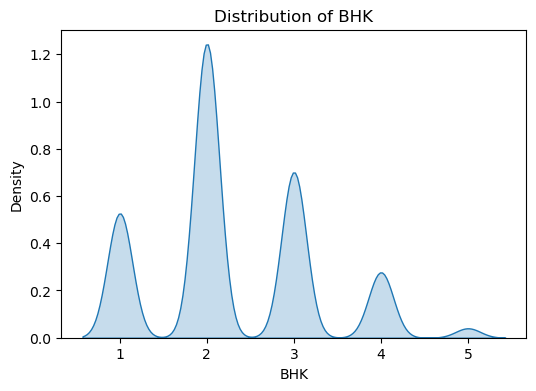

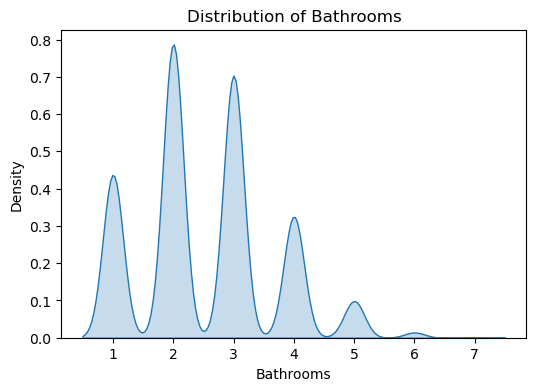

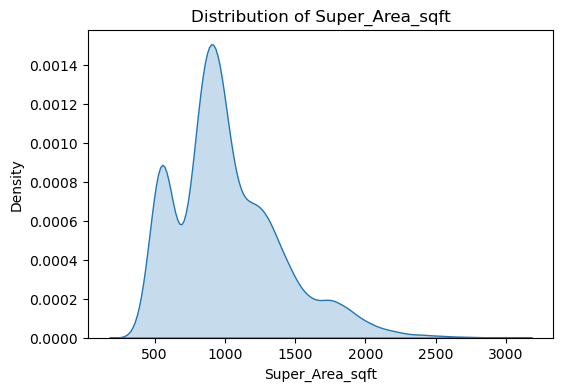

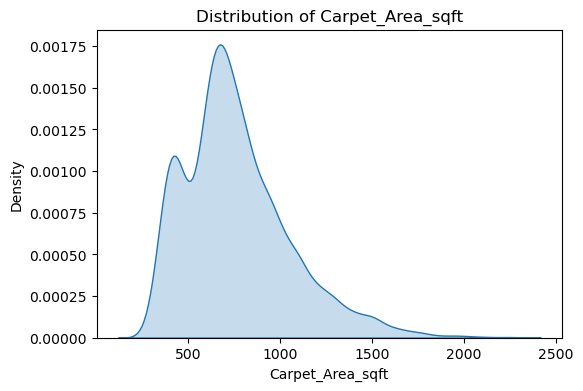

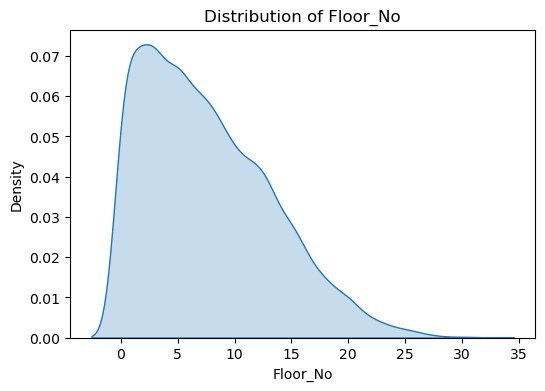

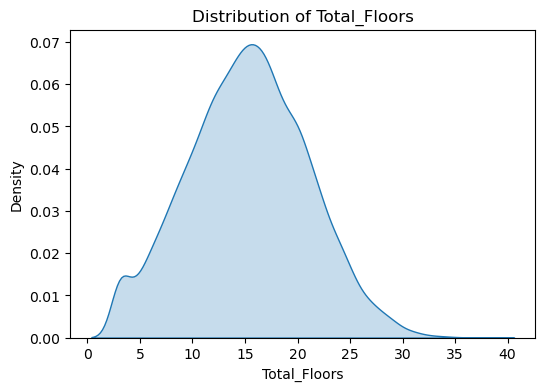

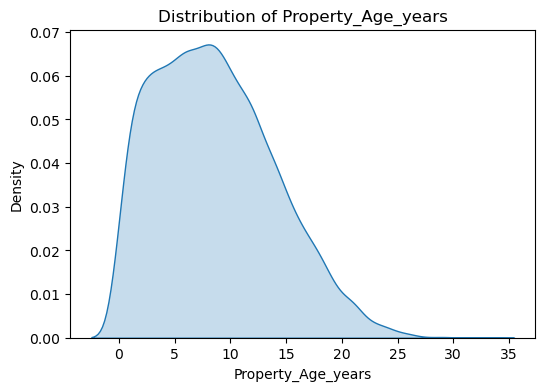

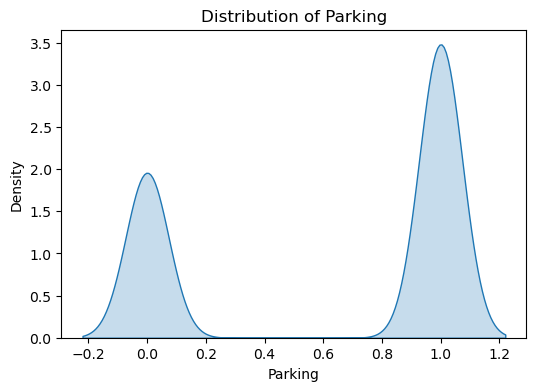

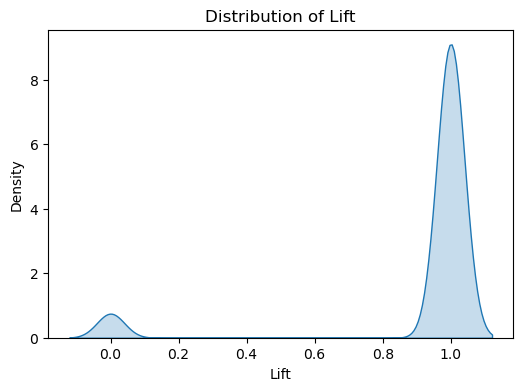

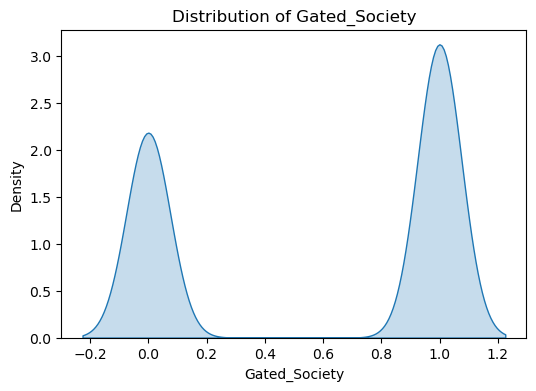

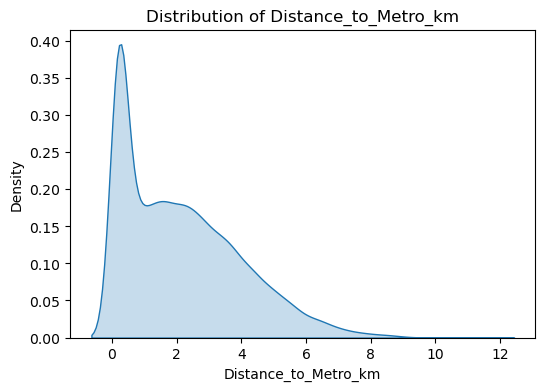

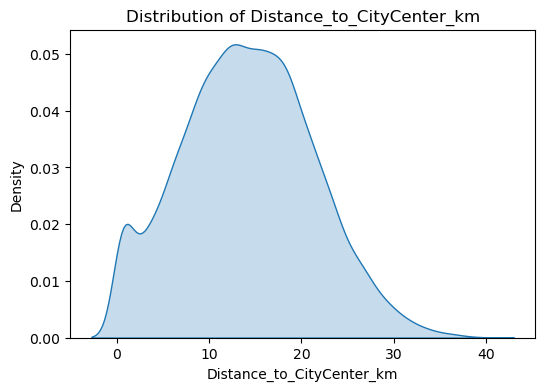

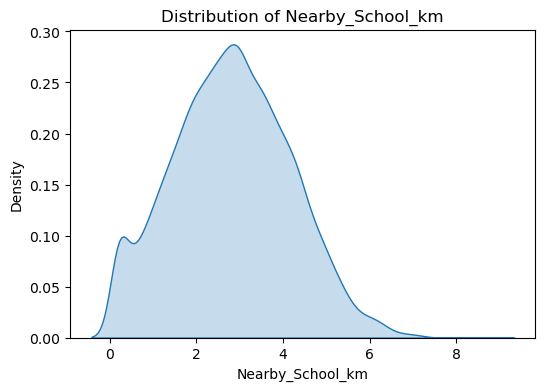

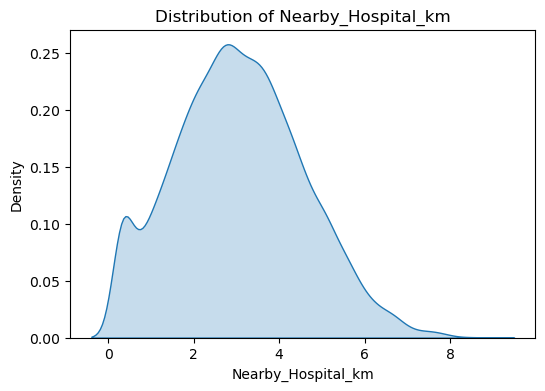

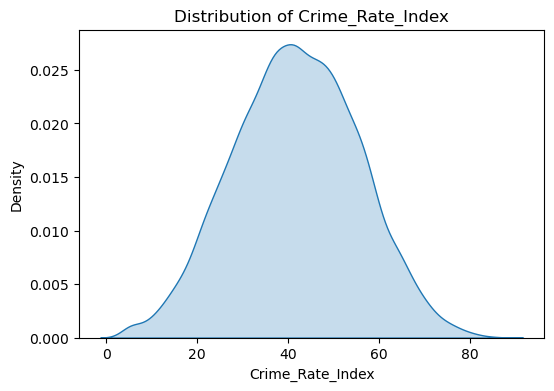

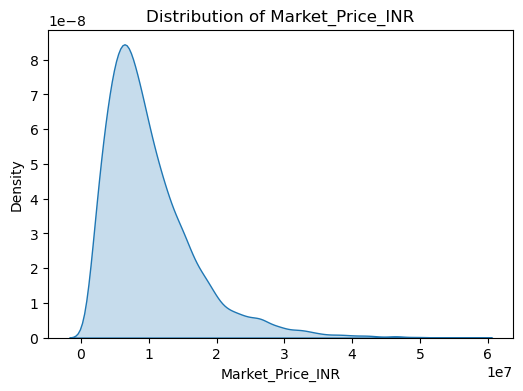

In [12]:
num_cols = df.select_dtypes(include=np.number).columns

for cols in num_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(
       data = df,
        x = cols,
        fill =True,
        
    )
    plt.title(f"Distribution of {cols}")
    plt.show()

In [13]:
x = df.drop(['Market_Price_INR'],axis = 1)
y = df.iloc[:,-1]

# PREPROCESSING PIPELINE


In [28]:
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [15]:
from sklearn import set_config
set_config(display='diagram')

In [16]:
numeric_features = [
    "BHK",
    "Bathrooms",
    "Super_Area_sqft",
    "Carpet_Area_sqft",
    "Floor_No",
    "Total_Floors",
    "Property_Age_years",
    "Distance_to_Metro_km",
    "Distance_to_CityCenter_km",
    "Nearby_School_km",
    "Nearby_Hospital_km",
    "Crime_Rate_Index"
]

binary_features = [
    "Parking",
    "Lift",
    "Gated_Society"
]

categorical_features = [
    "City",
    "Locality_Tier",
    "Furnishing"
]

onehot_feature = ['City']
ord_feature = ["Locality_Tier","Furnishing"]

In [17]:
numeric_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaling',StandardScaler())
])

In [18]:
ordinal_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ordinal',OrdinalEncoder(categories=
     [['Budget','Mid','Premium'],['Unfurnished','Semi-Furnished','Fully-Furnished']]))
])

In [19]:
onehot_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown="ignore",sparse_output=False,drop='first'))
])

In [20]:
preprocessor = ColumnTransformer(transformers=[
    ('numeric_pipeline',numeric_pipeline,numeric_features),
    ('ordinal_pipeline',ordinal_pipeline,ord_feature),
    ('onehot_pipeline',onehot_pipeline,onehot_feature)] ,remainder='passthrough')

In [21]:
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('numeric_pipeline',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaling',
                                                  StandardScaler())]),
                                 ['BHK', 'Bathrooms', 'Super_Area_sqft',
                                  'Carpet_Area_sqft', 'Floor_No',
                                  'Total_Floors', 'Property_Age_years',
                                  'Distance_to_Metro_km',
                                  'Distance_to_CityCenter_km',
                                  'Nearby_School_km', 'Nearby_H...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Budget',
                                                                              'Mid',
                                                                              'Premium'],
                                                                             ['Unfurnished',
                                                                              'Semi-Furnished',
                                                                              'Fully-Furnished']]))]),
                                 ['Locality_Tier', 'Furnishing']),
                                ('onehot_pipeline',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['City'])])

In [22]:
x_train,x_test,y_train,y_test = train_test_split(x,y ,random_state=42 ,test_size=0.2)

In [23]:
x_train_transformed = preprocessor.fit_transform(x_train)
x_test_transformed  = preprocessor.transform(x_test)

# MODEL TRAINING

In [24]:
lr = LinearRegression()

In [25]:
lr.fit(x_train_transformed,y_train)

LinearRegression()

In [26]:
y_pred = lr.predict(x_test_transformed)

# MODEL EVALUATION

In [27]:
r2_score(y_test,y_pred)

0.9126616564336523

In [31]:
np.mean(cross_val_score(lr,x_test_transformed,y_test,scoring='r2',cv = 10))

0.9122492446927082

# MODEL EXPORTING

In [32]:
import pickle
pickle.dump(preprocessor,open('preprocessor.pkl','wb'))

pickle.dump(lr,open('model.pkl','wb'))